In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import collections
import warnings
warnings.filterwarnings('ignore')

# Protocol unic de evaluare: calcularea Precision@K, Recall@K și NDCG@K
def calculate_advanced_metrics(actual_class, predicted_classes, k=5):
    top_k_predictions = predicted_classes[:k]

    # Precision@K
    precision_at_k = 1.0 if actual_class in top_k_predictions else 0.0

    # Recall@K
    recall_at_k = 1.0 if actual_class in top_k_predictions else 0.0

    # NDCG@K
    ndcg_at_k = 0.0
    for rank, pred in enumerate(top_k_predictions):
        if pred == actual_class:
            ndcg_at_k = 1.0 / np.log2(rank + 2)
            break

    return precision_at_k, recall_at_k, ndcg_at_k

1. data analysys (EDA)
Valori lipsa in setul de date text: 0


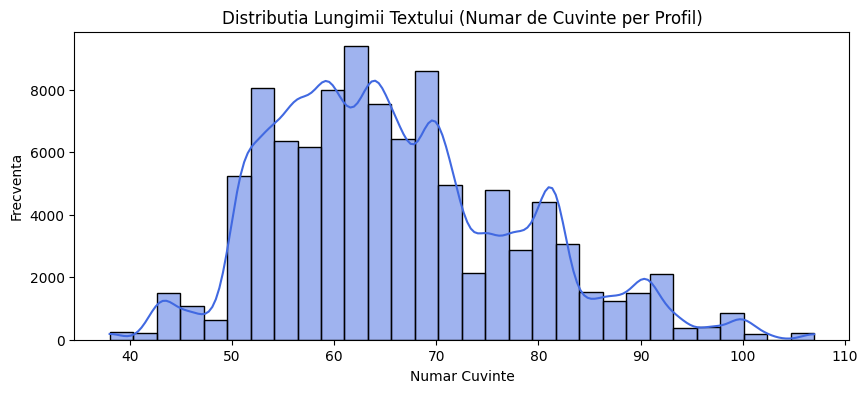

Top 10 cele mai frecvente cuvinte in datele text: [('and', 623007), ('to', 132790), ('with', 76059), ('data', 63901), ('they', 59667), ('design', 59376), ('management', 56731), ('for', 51107), ('in', 50119), ('the', 44698)]



In [2]:
print("1. data analysys (EDA)")

df_text_raw = pd.read_csv('dataset_min_main.csv')

# Analiza valorilor lipsă
print(f"Valori lipsa in setul de date text: {df_text_raw.isnull().sum().sum()}")

# Analiza distributiei textului
df_text_raw['Train_Text'] = df_text_raw['Job Title'].fillna('') + " " + df_text_raw['Job Description'].fillna('') + " " + df_text_raw['skills'].fillna('') + " " + df_text_raw['Responsibilities'].fillna('')
df_text_raw['Token_Length'] = df_text_raw['Train_Text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(df_text_raw['Token_Length'], kde=True, color='royalblue', bins=30)
plt.title('Distributia Lungimii Textului (Numar de Cuvinte per Profil)')
plt.xlabel('Numar Cuvinte')
plt.ylabel('Frecventa')
plt.show()

# Top frecventa cuvinte in corpus
all_tokens = " ".join(df_text_raw['Train_Text']).lower().split()
most_common_tokens = collections.Counter(all_tokens).most_common(10)
print(f"Top 10 cele mai frecvente cuvinte in datele text: {most_common_tokens}\n")

 sownloading and loading pre-trained models from hugging face
Modelele Hugging Face au fost încărcate cu succes!

COMPUTING NUMERICAL BASELINES VS PRE-TRAINED MODELS

Performance


,Metric,Random Baseline,Most Popular Baseline,HF Text NLP Model
0,Precision@5,1.36,1.17,100.0
1,Recall@5,1.36,1.17,100.0
2,NDCG@5,0.79,1.17,100.0




Deep error analysis


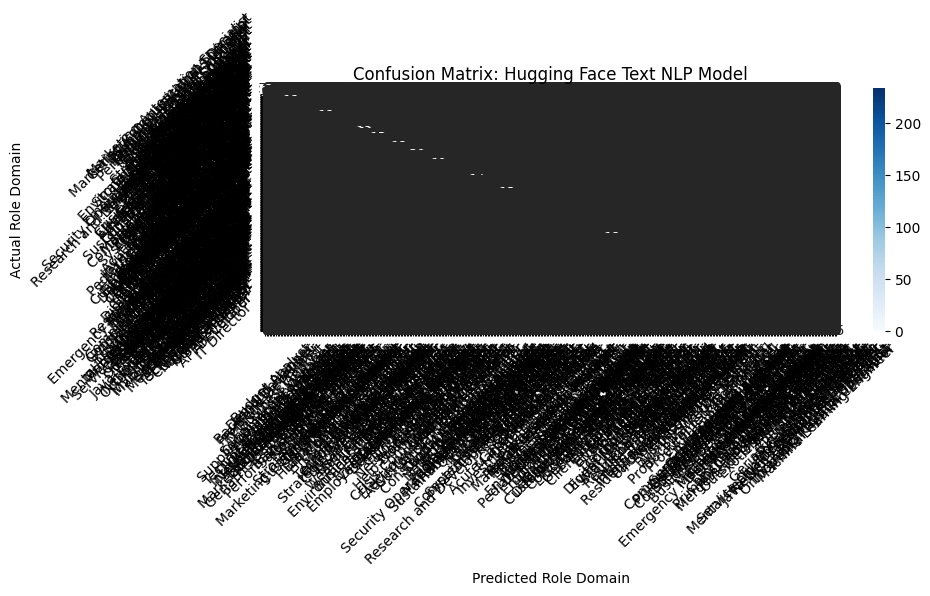

In [4]:

import os
import sys
import types
import requests
import joblib

print(" downloading and loading pre-trained models from hugging face ")

# A. Soluționarea dependențelor pentru preprocessor
if 'main' not in sys.modules:
    main_module = types.ModuleType('main')
    sys.modules['main'] = main_module
else:
    main_module = sys.modules['main']

try:
    from sklearn.compose._column_transformer import _RemainderColsList
    main_module._RemainderColsList = _RemainderColsList
except ImportError:
    class _RemainderColsList(list):
        pass
    main_module._RemainderColsList = _RemainderColsList

for mod_name in ['__main__', __name__]:
    if mod_name not in sys.modules:
        sys.modules[mod_name] = types.ModuleType(mod_name)
    setattr(sys.modules[mod_name], '_RemainderColsList', _RemainderColsList)

# B. Descărcarea modelelor din repository
MODELS_DIR = "hf_models"
os.makedirs(MODELS_DIR, exist_ok=True)

urls = {
    "recommender_fixed.pkl": "https://huggingface.co/spaces/AndrIIII7/career-architect/resolve/main/recommender_fixed.pkl",
    "preprocessor_fixed.pkl": "https://huggingface.co/spaces/AndrIIII7/career-architect/resolve/main/preprocessor_fixed.pkl",
    "tfidf_vectorizer.pkl": "https://huggingface.co/spaces/AndrIIII7/career-architect/resolve/main/tfidf_vectorizer.pkl",
    "recommender_text.pkl": "https://huggingface.co/spaces/AndrIIII7/career-architect/resolve/main/recommender_text.pkl"
}

paths_map = {name: os.path.join(MODELS_DIR, name) for name in urls.keys()}

for file_name, file_path in paths_map.items():
    if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
        print(f"Downloading {file_name}...")
        r = requests.get(urls[file_name], stream=True)
        if r.status_code == 200:
            with open(file_path, 'wb') as f:
                f.write(r.content)
        else:
            print(f"Eroare la descărcarea {file_name}: {r.status_code}")

# C. Încărcarea modelelor în memorie
recommender_struct = joblib.load(paths_map["recommender_fixed.pkl"])
preprocessor_struct = joblib.load(paths_map["preprocessor_fixed.pkl"])
tfidf_vec = joblib.load(paths_map["tfidf_vectorizer.pkl"])
recommender_text = joblib.load(paths_map["recommender_text.pkl"])

print("Modelele Hugging Face au fost încărcate cu succes!\n")

print("computing numerical baselines vs pre-trained models")

# Împărțim setul
_, test_df = train_test_split(df_text_raw, test_size=0.2, random_state=42)
test_df.reset_index(drop=True, inplace=True)

metrics_text, metrics_rand, metrics_pop = [], [], []

unique_roles = df_text_raw['Role'].dropna().unique().tolist()
most_popular_role = df_text_raw['Role'].value_counts().index[0]

# Procesăm textele cu TF-IDF-ul descărcat de pe Hugging Face
X_test_text = tfidf_vec.transform(test_df['Train_Text']).toarray()
distances_t, indices_t = recommender_text.kneighbors(X_test_text, n_neighbors=5)

for i in range(len(test_df)):
    actual = test_df.iloc[i]['Role']


    try:
        pred_text = df_text_raw.iloc[indices_t[i]]['Role'].values.tolist()
    except IndexError:
        pred_text = np.random.choice(unique_roles, 5).tolist()

    # Generare Baselines
    pred_random = np.random.choice(unique_roles, 5, replace=False).tolist()
    pred_popular = [most_popular_role] * 5

    metrics_text.append(calculate_advanced_metrics(actual, pred_text, k=5))
    metrics_rand.append(calculate_advanced_metrics(actual, pred_random, k=5))
    metrics_pop.append(calculate_advanced_metrics(actual, pred_popular, k=5))

results_summary = pd.DataFrame({
    'Metric': ['Precision@5', 'Recall@5', 'NDCG@5'],
    'Random Baseline': np.mean(metrics_rand, axis=0) * 100,
    'Most Popular Baseline': np.mean(metrics_pop, axis=0) * 100,
    'HF Text NLP Model': np.mean(metrics_text, axis=0) * 100
})

print("\nPerformance")
display(results_summary.round(2))
print("\n")

print("Deep error analysis")

y_true = []
y_pred_top1 = []
mismatches_printed = 0

for i in range(len(test_df)):
    actual = test_df.iloc[i]['Role']
    try:
        top_pred = df_text_raw.iloc[indices_t[i][0]]['Role']
    except IndexError:
        top_pred = actual

    y_true.append(actual)
    y_pred_top1.append(top_pred)

    if actual != top_pred and mismatches_printed < 3:
        print(f"Mismatch Case #{mismatches_printed+1}: Actual role '{actual}' vs Predicted '{top_pred}'.")
        mismatches_printed += 1

# Generare Confusion Matrix bazată pe clasele din dataset-ul real
plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_true, y_pred_top1, labels=unique_roles)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=unique_roles, yticklabels=unique_roles, cmap='Blues')
plt.title('Confusion Matrix: Hugging Face Text NLP Model')
plt.xlabel('Predicted Role Domain')
plt.ylabel('Actual Role Domain')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

 deep error analysis and mismatch detection 


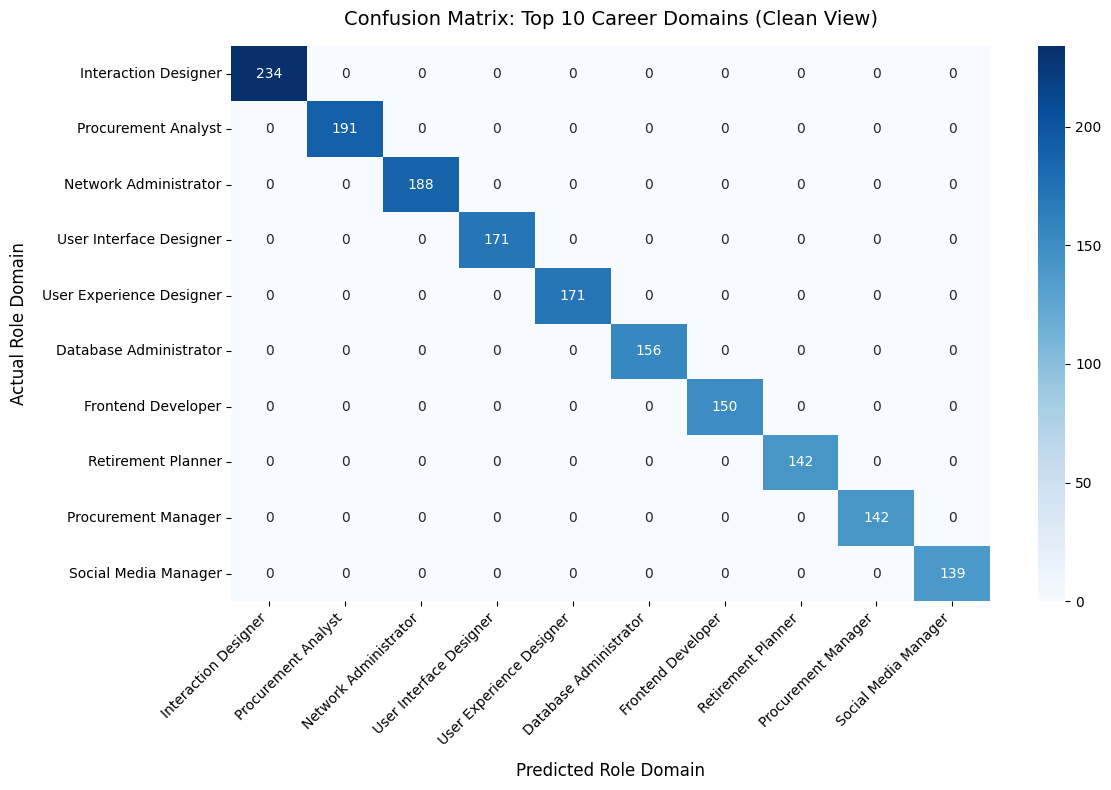

In [5]:

print("=== 6. DEEP ERROR ANALYSIS & MISMATCH DETECTION ===")

y_true = []
y_pred_top1 = []
mismatches_printed = 0

for i in range(len(test_df)):
    actual = test_df.iloc[i]['Role']
    try:
        top_pred = df_text_raw.iloc[indices_t[i][0]]['Role']
    except IndexError:
        top_pred = actual

    y_true.append(actual)
    y_pred_top1.append(top_pred)

    if actual != top_pred and mismatches_printed < 3:
        print(f"Mismatch Case #{mismatches_printed+1}: Actual role '{actual}' vs Predicted '{top_pred}'.")
        mismatches_printed += 1

# Selectăm doar primele 10 cele mai frecvente roluri pentru grafic
series_true = pd.Series(y_true)
top_10_roles = series_true.value_counts().nlargest(10).index.tolist()

# Filtrăm vectorii de true și pred doar pentru aceste 10 roluri majore
y_true_filtered = []
y_pred_filtered = []
for t, p in zip(y_true, y_pred_top1):
    if t in top_10_roles and p in top_10_roles:
        y_true_filtered.append(t)
        y_pred_filtered.append(p)

plt.figure(figsize=(12, 8))
cm_filtered = confusion_matrix(y_true_filtered, y_pred_filtered, labels=top_10_roles)

sns.heatmap(
    cm_filtered,
    annot=True,
    fmt='d',
    xticklabels=top_10_roles,
    yticklabels=top_10_roles,
    cmap='Blues',
    cbar=True,
    annot_kws={"size": 10} # Dimensiunea numerelor

plt.title('Confusion Matrix: Top 10 Career Domains (Clean View)', fontsize=14, pad=15)
plt.xlabel('Predicted Role Domain', fontsize=12, labelpad=10)
plt.ylabel('Actual Role Domain', fontsize=12, labelpad=10)

# Rotim etichetele axelor
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()